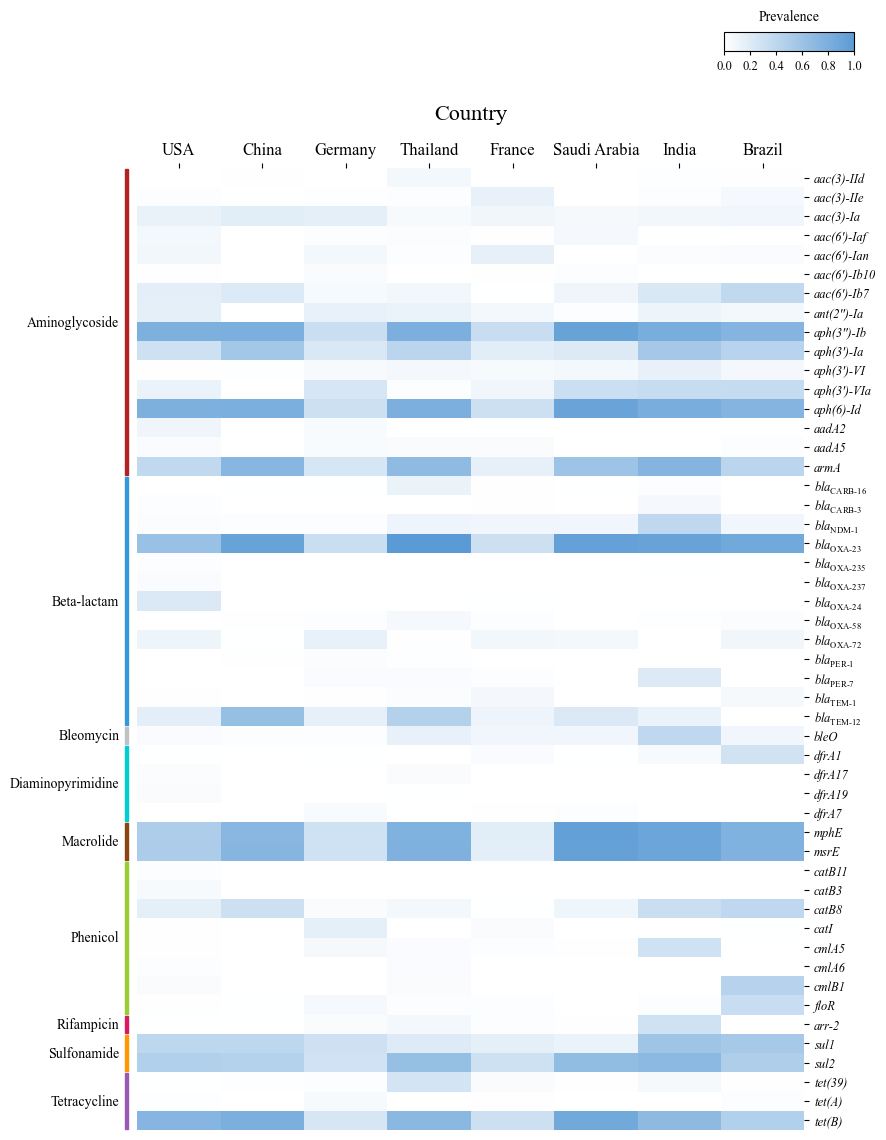

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# ================= 1. 读取数据 =================
df_args = pd.read_csv(r'D:\A.baumannii\data\ARGs_matched_representatives.csv')#耐药基因整理成0和1的文件
df_meta = pd.read_csv(r'D:\A.baumannii\data\antibiotic_classes_matched_metadata.csv') #基本信息文件，宿主国家地区

try:
    df_class = pd.read_csv(r'D:\A.baumannii\data\acquired_ARGs_classify.csv', encoding='gbk')#剔除固有基因的抗生素类别表
except UnicodeDecodeError:
    df_class = pd.read_csv(r'D:\A.baumannii\data\acquired_ARGs_classify.csv', encoding='utf-8')

# ================= 2. 数据清洗与基因分类映射 =================
gene_to_class = {}
df_class['Classify'] = df_class['Classify'].ffill()

for idx, row in df_class.iterrows():
    if pd.isna(row['Classify']) or pd.isna(row['gene']):
        continue
        
    classify_name = str(row['Classify']).split('(')[-1].replace(')', '').strip()
    genes = str(row['gene']).replace('，', ',').split(',')
    
    for g in genes:
        g = g.strip()
        if g and (g not in gene_to_class):
            gene_to_class[g] = classify_name

# ================= 3. 筛选在分类文件中出现过的 Top 60 基因 =================
all_gene_columns = df_args.columns[2:]
valid_genes = [g for g in all_gene_columns if g in gene_to_class]
gene_sums = df_args[valid_genes].sum().sort_values(ascending=False)
top_60_genes = gene_sums.head(50).index.tolist()

if not top_60_genes:
    raise ValueError("未找到匹配的基因，请检查大小写！")

# ================= 4. 修改点：按国家筛选并计算流行率 =================
# 读取 country 列而不是 year 列
df_merged = pd.merge(df_args[['Genome_ID'] + top_60_genes], 
                     df_meta[['Genome_ID', 'country']], 
                     on='Genome_ID', how='inner')

# 剔除国家为空的数据
df_merged = df_merged.dropna(subset=['country'])

# 统计各个国家的样本量，并提取数量最多的前 8 个国家
country_counts_full = df_merged['country'].value_counts()
top_8_countries = country_counts_full.head(8).index.tolist()

# 仅保留这 8 个国家的数据
df_merged = df_merged[df_merged['country'].isin(top_8_countries)]
country_counts = df_merged['country'].value_counts()

# 按国家分组计算流行率 (均值)，并转置
prevalence_df = df_merged.groupby('country')[top_60_genes].mean().T

# 强制将列顺序按照样本量从大到小（前8名）排序
prevalence_df = prevalence_df[top_8_countries]

# ================= 5. 构建热图所需的数据结构 =================
plot_data = prevalence_df.reset_index().rename(columns={'index': 'Gene'})
plot_data['Class'] = plot_data['Gene'].map(gene_to_class)

# 补全 Beta-lactam 类的 bla 前缀
plot_data['Gene'] = plot_data.apply(
    lambda row: f"bla{row['Gene']}" if row['Class'] == 'Beta-lactam' and not row['Gene'].lower().startswith('bla') else row['Gene'], 
    axis=1
)

# 格式化基因名称 (大写转小写，处理 bla 下标)
def format_gene_name(gene):
    gene_str = str(gene)
    if gene_str.startswith(("APH", "AAC", "ANT")):
        gene_str = gene_str[:3].lower() + gene_str[3:]
        
    if gene_str.startswith("bla"):
        suffix = gene_str[3:]
        suffix_math = suffix.replace('-', r'}\text{-}\mathrm{')
        return rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$'
    
    return gene_str

plot_data['Gene_Display'] = plot_data['Gene'].apply(format_gene_name)

# 设置为索引并排序
plot_data = plot_data.sort_values(by=['Class', 'Gene']).set_index('Gene_Display')
class_labels = plot_data['Class']

# 提取用于热图的列（此时已经是排序好的前8个国家）
heatmap_data = plot_data[[c for c in top_8_countries if c in plot_data.columns]]

# ================= 6. 绘图与排版设计 =================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'

custom_colors = ["#FFFFFF",  "#5B9BD5"] 
custom_cmap = LinearSegmentedColormap.from_list("custom_blues", custom_colors)

fig = plt.figure(figsize=(10, 13)) # 略微加宽画布以适应 8 个国家
gs = fig.add_gridspec(1, 2, width_ratios=[0.6, 4], wspace=0.02)
ax_labels = fig.add_subplot(gs[0])
ax_heat = fig.add_subplot(gs[1])

sns.heatmap(heatmap_data, cmap=custom_cmap, ax=ax_heat, 
            cbar=False, 
            linewidths=0, linecolor='white') 

# 基因名称标签
ax_heat.yaxis.tick_right()
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), rotation=0, fontsize=9, fontstyle='italic')
ax_heat.set_ylabel('')

# ================= 核心修改：顶部国家与严格样本量格式 =================
ax_heat.xaxis.tick_top()
ax_heat.xaxis.set_label_position('top')

# 严格按照要求格式化标签：上方国家名，换行，下方 n = xxx (注意等号两边加空格)
xtick_labels = [f"{col}" for col in heatmap_data.columns]
ax_heat.set_xticklabels(xtick_labels, fontsize=12)



# 设置总标题
ax_heat.set_title('Country', fontsize=16, pad=35) 
ax_heat.set_xlabel('')

# 绘制左侧抗生素类别与彩条
ax_labels.axis('off')
ax_labels.set_ylim(len(heatmap_data), 0)

unique_classes = class_labels.unique()
current_y = 0

exact_color_map = {
    'Aminoglycoside': '#B22222',      
    'Beta-lactam': '#3498DB',         
    'Polymyxins': '#E74C3C',           
    'Fosfomycin': '#2ECC71',           
    'Fluoroquinolone': '#F1C40F',     
    'Quinolone': '#F1C40F',            
    'Macrolide': '#8B4513',            
    'Lincosamide': '#8B4513',          
    'Phenicol': '#9ACD32',                        
    'Rifampicin': '#D81B60',           
    'Sulfonamide': '#FF9800',          
    'Tetracycline': '#9B59B6',        
    'Diaminopyrimidine': '#00CED1',    
    'Trimethoprim': '#00CED1',         
    'Glycopeptide': '#95A5A6',         
    'Vancomycin': '#95A5A6',           
    'Nucleoside': '#7F8C8D',           
    'Bleomycin': '#BDC3C7'             
}

for cls in unique_classes:
    count = (class_labels == cls).sum()
    y_center = current_y + count / 2
    
    ax_labels.text(0.9, y_center, cls, ha='right', va='center',rotation=0, fontsize=10)
    bar_color = exact_color_map.get(cls, '#B0BEC5')
    
    rect = Rectangle((0.95, current_y + 0.05), 0.03, count - 0.1, 
                     fill=True, color=bar_color, clip_on=False)
    ax_labels.add_patch(rect)
    current_y += count

# ================= 7. 图例 (Colorbar) =================
cbar_ax = fig.add_axes([0.82, 0.94, 0.13, 0.015]) 
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=custom_cmap), 
                  cax=cbar_ax, orientation='horizontal')
cb.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
cb.ax.tick_params(labelsize=9, length=3, direction='out')
cbar_ax.set_title('Prevalence', fontsize=10, pad=8)

cb.outline.set_visible(True)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(0.8)

plt.subplots_adjust(top=0.85)

# 保存和显示
plt.savefig('D:/python/敏感性分析/第二部分/ARGs_Country_Top8_Heatmap.png', dpi=600, bbox_inches='tight')
plt.show()